### About the Dataset

The **Loan Eligibility Prediction** dataset contains information about loan applicants and their financial and personal characteristics. The dataset is used to analyze the factors associated with loan approval and to build a machine learning model that predicts whether a loan application will be approved or rejected.

The target variable is **`Loan_Status`**, which represents the loan approval status.

The dataset includes applicant-related information such as:

* Gender
* Married status
* Dependents
* Education
* Self-employed status
* Applicant income
* Co-applicant income
* Loan amount
* Loan term
* Credit history
* Property area

In this project, the data is preprocessed and categorical features are encoded before training a **Decision Tree Classification model**. The model is then evaluated using accuracy, confusion matrix, precision, recall, and F1-score to understand its classification performance.
::: 

Source: [Kaggle – Loan Eligibility Prediction Dataset](https://www.kaggle.com/datasets/avineshprabhakaran/loan-eligibility-prediction?utm_source=chatgpt.com)


## Objective
The objective of this project is to build a **Decision Tree Classification model** to predict the `Loan_Status` of loan applicants based on their demographic, financial, and loan-related features.

The project aims to:

* Perform data preprocessing and handle missing values and categorical features.
* Encode categorical variables for machine learning.
* Train a Decision Tree Classifier for **binary classification**.
* Evaluate model performance using **accuracy, confusion matrix, precision, recall, and F1-score**.
* Analyze **feature importance** to understand which factors contribute most to loan approval predictions.
* Visualize the Decision Tree to improve model interpretability.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Loan Eligibility Prediction.csv")

In [3]:
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [5]:
df.isna().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

In [8]:
df = df.drop(["Customer_ID","Education"],axis = 1)

In [11]:
df = pd.get_dummies(df,columns=[
    "Gender",
    "Married",
    "Self_Employed",
    "Property_Area"
],
   drop_first = True,
   dtype = int)

In [12]:
df

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,2378,0.0,9,360,1,N,0,0,0,0,1
1,2,1299,1086.0,17,120,1,Y,1,1,0,0,1
2,0,3620,0.0,25,120,1,Y,1,0,0,1,0
3,0,3459,0.0,25,120,1,Y,1,1,1,1,0
4,1,5468,1032.0,26,360,1,Y,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
609,2,2947,1603.0,10,360,1,N,1,1,0,0,1
610,0,4680,2087.0,15,360,1,N,1,0,0,1,0
611,2,6633,0.0,25,360,0,N,1,1,1,0,0
612,1,2492,2375.0,30,360,1,Y,1,1,0,0,0


**Prediction Target** </br>

The prediction target is Loan_Status, which represents whether a loan application is approved or not.</br>

**Y** → *Loan Approved* </br>
**N** → *Loan Not Approved* </br>

This is a binary classification problem because the model predicts one of two possible outcomes.

In [13]:
x = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [14]:
x

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,2378,0.0,9,360,1,0,0,0,0,1
1,2,1299,1086.0,17,120,1,1,1,0,0,1
2,0,3620,0.0,25,120,1,1,0,0,1,0
3,0,3459,0.0,25,120,1,1,1,1,1,0
4,1,5468,1032.0,26,360,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
609,2,2947,1603.0,10,360,1,1,1,0,0,1
610,0,4680,2087.0,15,360,1,1,0,0,1,0
611,2,6633,0.0,25,360,0,1,1,1,0,0
612,1,2492,2375.0,30,360,1,1,1,0,0,0


In [15]:
y

0      N
1      Y
2      Y
3      Y
4      Y
      ..
609    N
610    N
611    N
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: object

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size = 0.20, random_state = 42, stratify = y
)

In [17]:
model = DecisionTreeClassifier(
    criterion = 'gini', max_depth = None, random_state = 42
)

In [18]:
model

DecisionTreeClassifier(random_state=42)

In [19]:
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
y_test_pred = model.predict(x_test)

In [21]:
y_test_pred

array(['N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N',
       'N', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'N'], dtype=object)

In [22]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Prediction" : y_test_pred
})

In [23]:
comparison

,Actual,Prediction
158,N,N
552,Y,N
590,Y,N
231,Y,Y
142,Y,Y
...,...,...
353,Y,N
296,N,N
7,N,Y
281,Y,Y


In [25]:
accuracy = accuracy_score(y_test,y_test_pred)*100
print(f"Accuracy Score: {accuracy:.2f}%")

Accuracy Score: 69.11%


In [26]:
classification = classification_report(y_test,y_test_pred,
                                      target_names = ["Yes","No"])

print("Classification Report:\n", classification)

Classification Report:
               precision    recall  f1-score   support

         Yes       0.50      0.58      0.54        38
          No       0.80      0.74      0.77        85

    accuracy                           0.69       123
   macro avg       0.65      0.66      0.65       123
weighted avg       0.71      0.69      0.70       123



In [27]:
cm = confusion_matrix(y_test,y_test_pred)

In [28]:
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[22 16]
 [22 63]]


In [29]:
from sklearn.tree import plot_tree

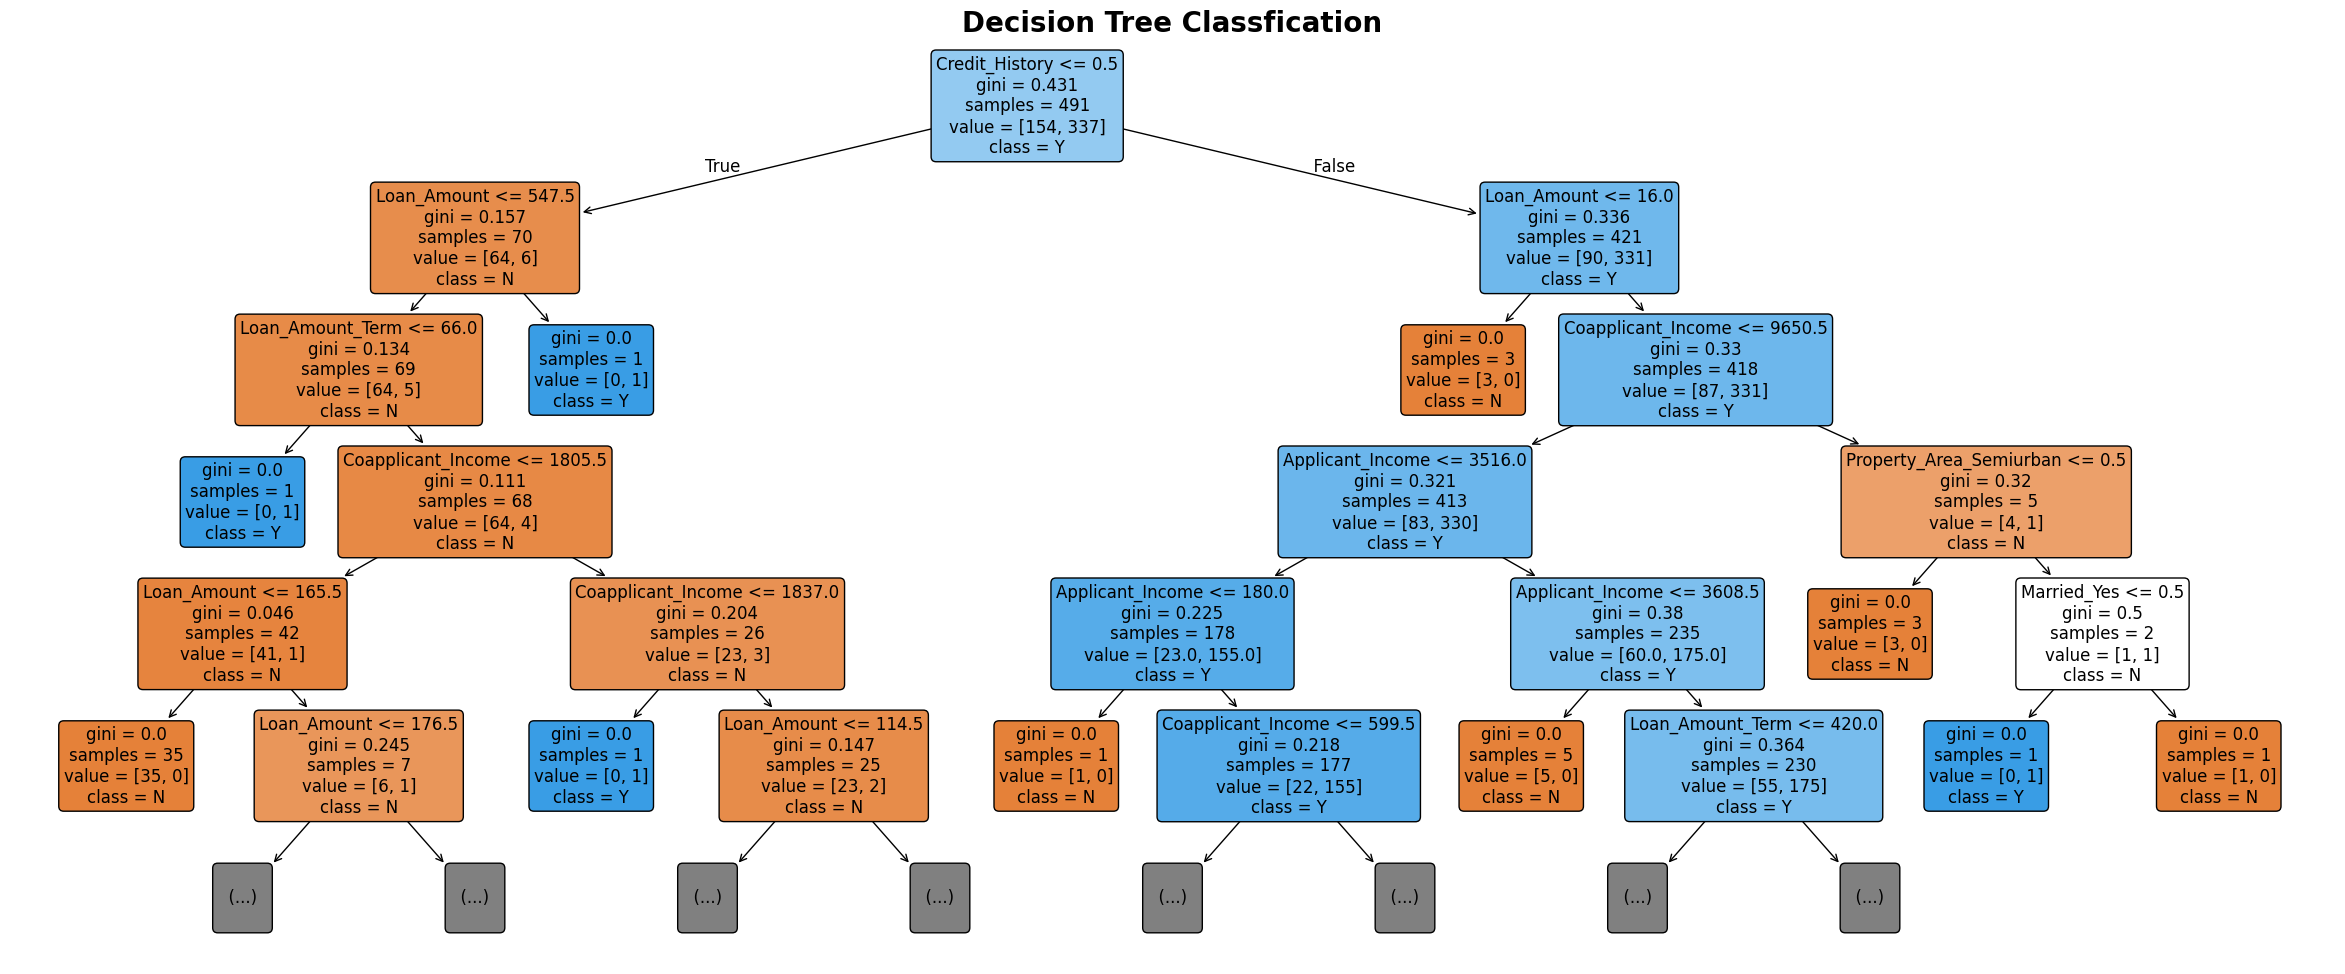

In [36]:
plt.figure(figsize=(30,12))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize = 12
)
plt.title("Decision Tree Classfication",fontsize=20,fontweight = 'bold')
plt.show()

## Conclusion

The Decision Tree Classification model achieved an accuracy of **69.11%** on the test dataset. The model performed better in predicting **No** loan eligibility, with an F1-score of **0.77**, compared to **0.54** for the Yes class. The results show that the model can predict loan eligibility, but further improvement is needed, especially for the **Yes** class.